# 02 — Walk-Forward Training & Cross-Model IC Comparison

I train four cross-sectional ranking models on expanding annual windows, collect their out-of-sample predictions, and compare them against a handmade equal-weight baseline. The question I'm really asking is not "does the boosted model post the highest IC?" — it's whether the extra machinery buys anything over naively combining the three features that already had positive IC in `01_feature_eda`.

**Models.**
| Model | Role | Notes |
|---|---|---|
| `linear_ridge` | Linear baseline | Ridge on per-date z-scored features. |
| `linear_lasso` | Sparse linear | Lasso; should zero out the redundant wrong-sign momentum series. |
| `lgbm_ranker` | Main tree model | LightGBM `LGBMRanker`, pairwise rank objective with decile labels. |
| `xgb_ranker` | Robustness check | XGBoost `XGBRanker`, same structure. |
| `naive_ew` | Yardstick | Equal-weight z-score of `size_adv_60 + vol_60d + reversal_1w`. |

**Walk-forward.** For each OOS year Y ∈ {2020..2024}, I train on all data with `date < Jan 1 Y` and predict year Y. Expanding window, re-train yearly. No purging — at a monthly horizon with annual retrain, the embargo gain is negligible relative to fold noise.

**Target.** Tree models consume integer decile labels per date (0..9, `qcut(fwd_rank_21d, 10)`). Linear models predict the continuous `fwd_rank_21d` directly. Both are evaluated on the same model-agnostic metric: per-date Spearman IC of predicted score vs actual forward return rank.

**Feature set.** All 12 features from `01_feature_eda`, minus `low_vol_60` which is a sign-flipped duplicate of `vol_60d`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mlcs.model import (
    EqualWeightBaseline,
    LGBMRankerModel,
    LinearRanker,
    XGBRankerModel,
)
from mlcs.validation import walk_forward_years

PROC_DIR = Path("../data/processed")
REPORTS_DIR = Path("../reports")
FIG_DIR = REPORTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
(REPORTS_DIR / "predictions").mkdir(parents=True, exist_ok=True)

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 110

In [2]:
candidates = sorted(PROC_DIR.glob("features_*.parquet"))
assert candidates, "Run scripts/build_features.py first."
df = pd.read_parquet(candidates[-1])
df["date"] = pd.to_datetime(df["date"])

# feature set per 01_feature_eda conclusions
FEATURES = [
    "mom_12_1", "reversal_1w", "size_adv_60",
    "ret_21d", "ret_63d", "ret_126d", "ret_252d",
    "vol_20d", "vol_60d",
    "rsi_14", "macd_hist", "volume_z_60",
]
TARGET = "fwd_rank_21d"

# keep rows where at least the target and a majority of features are present;
# trees handle NaN internally, linear models need all features present and get
# an in-training mask in LinearRanker.fit.
work = df.dropna(subset=[TARGET]).copy()
print(f"working rows: {len(work):,}   date range: {work['date'].min().date()} → {work['date'].max().date()}")
print(f"features    : {len(FEATURES)}")

working rows: 1,280,581   date range: 2015-01-02 → 2025-06-30
features    : 12


## 1. Walk-forward training loop

Each fold trains 5 models on `< Jan 1 Y` and predicts year Y. OOS predictions stack into one long dataframe keyed by `(date, symbol, model)`. The main runtime cost is the two boosters — their fits grow with the expanding training window.

In [3]:
FIRST_OOS = 2020
LAST_OOS = 2024

def make_models():
    return [
        LinearRanker(kind="ridge", alpha=1.0),
        LinearRanker(kind="lasso", alpha=1e-4),
        LGBMRankerModel(n_estimators=400, num_leaves=31, learning_rate=0.05,
                        min_child_samples=100, random_state=42),
        XGBRankerModel(n_estimators=400, max_depth=5, learning_rate=0.05,
                       random_state=42),
        EqualWeightBaseline(),
    ]

import time

all_preds = []
for oos_year, tr_mask, te_mask in walk_forward_years(work["date"], FIRST_OOS, LAST_OOS):
    tr = work.loc[tr_mask]
    te = work.loc[te_mask]
    print(f"\n[{oos_year}] train={len(tr):,}  test={len(te):,}")
    for mdl in make_models():
        t0 = time.time()
        mdl.fit(tr[FEATURES], tr[TARGET], tr["date"])
        scores = mdl.predict(te[FEATURES], te["date"])
        dt = time.time() - t0
        out = te[["date", "symbol", TARGET]].copy()
        out["model"] = mdl.name
        out["score"] = scores
        all_preds.append(out)
        print(f"   {mdl.name:14s}  fit+predict {dt:5.1f}s")

preds = pd.concat(all_preds, ignore_index=True)
print("\nstacked OOS predictions:", preds.shape)


[2020] train=596,371  test=123,454


   linear_ridge    fit+predict   0.5s


   linear_lasso    fit+predict   0.6s


   lgbm_ranker     fit+predict  18.8s


   xgb_ranker      fit+predict  33.4s
   naive_ew        fit+predict   0.1s

[2021] train=719,825  test=124,432


...


[2024] train=1,093,230  test=126,135


   linear_ridge    fit+predict   0.8s


   linear_lasso    fit+predict   1.0s


   lgbm_ranker     fit+predict  31.4s


   xgb_ranker      fit+predict  64.1s
   naive_ew        fit+predict   0.1s

stacked OOS predictions: (3114970, 5)


In [4]:
# persist for W7 (backtest + SHAP) so we don't re-train downstream
out_path = REPORTS_DIR / "predictions" / f"oos_{FIRST_OOS}_{LAST_OOS}.parquet"
preds.to_parquet(out_path, index=False)
print("wrote", out_path, f"({out_path.stat().st_size / 1e6:.1f} MB)")

wrote ..\reports\predictions\oos_2020_2024.parquet (30.3 MB)


## 2. Per-date Spearman IC per model

For each (date, model) pair, I rank-correlate the predicted score against actual `fwd_rank_21d`. A cleanly positive IC on a given date means the model's ordering of stocks matched the actual forward-return ordering — the model-agnostic signal quality check.

In [5]:
def per_date_ic_model(frame: pd.DataFrame) -> pd.Series:
    def _ic(g):
        sub = g[["score", TARGET]].dropna()
        if len(sub) < 20:
            return np.nan
        return sub["score"].rank().corr(sub[TARGET])
    return frame.groupby("date").apply(_ic, include_groups=False)

ic_by_model = {m: per_date_ic_model(preds[preds["model"] == m]) for m in preds["model"].unique()}
ic_wide = pd.DataFrame(ic_by_model)
ic_wide.tail(3)

,linear_ridge,linear_lasso,lgbm_ranker,xgb_ranker,naive_ew
date,,,,,
2024-12-27,0.130472,0.128875,0.144405,0.160169,0.081411
2024-12-30,0.111749,0.110381,0.136279,0.163523,0.092805
2024-12-31,0.073492,0.071563,0.098572,0.145398,0.129793


In [6]:
rows = []
for m, s in ic_by_model.items():
    s = s.dropna()
    mean = s.mean()
    std = s.std()
    ir = mean / std if std > 0 else np.nan
    tstat = ir * np.sqrt(len(s)) if pd.notna(ir) else np.nan
    rows.append({
        "model":    m,
        "mean_ic":  round(mean, 4),
        "ic_std":   round(std, 4),
        "ic_ir":    round(ir, 3) if pd.notna(ir) else np.nan,
        "t_stat":   round(tstat, 2) if pd.notna(tstat) else np.nan,
        "hit_rate": round((s > 0).mean(), 3),
        "n_dates":  int(len(s)),
    })
summary = pd.DataFrame(rows).sort_values("ic_ir", ascending=False).reset_index(drop=True)
summary

,model,mean_ic,ic_std,ic_ir,t_stat,hit_rate,n_dates
0,xgb_ranker,0.0368,0.1877,0.196,6.95,0.567,1258
1,lgbm_ranker,0.0310,0.2174,0.143,5.06,0.545,1258
2,naive_ew,0.0213,0.1888,0.113,4.01,0.526,1258
3,linear_lasso,0.0167,0.2232,0.075,2.65,0.490,1258
4,linear_ridge,0.0162,0.2216,0.073,2.60,0.496,1258


## 3. Cumulative IC over OOS window

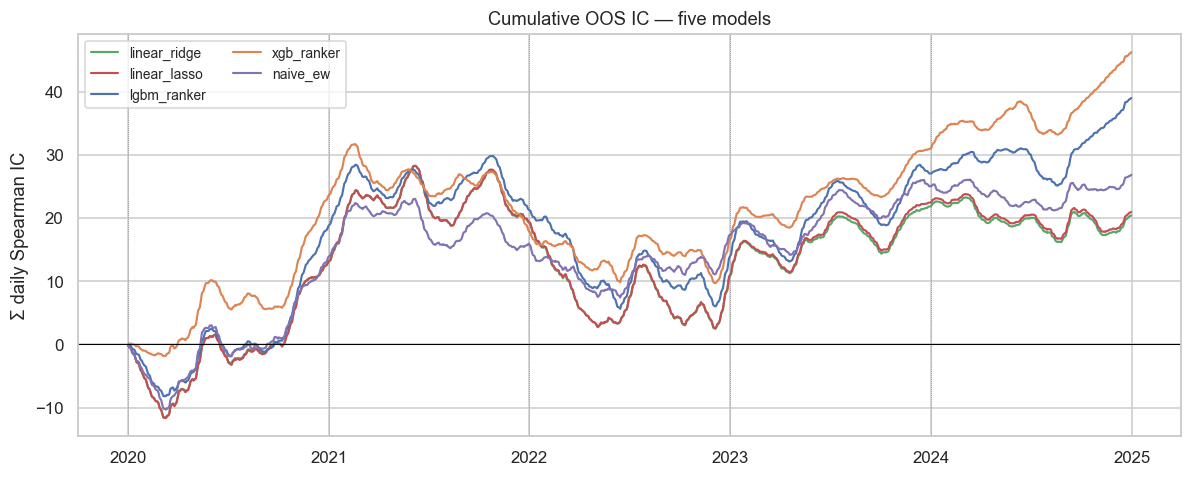

In [7]:
cum = ic_wide.cumsum()

fig, ax = plt.subplots(figsize=(11, 4.5))
palette = {"lgbm_ranker": "C0", "xgb_ranker": "C1",
           "linear_ridge": "C2", "linear_lasso": "C3", "naive_ew": "C4"}
for m in cum.columns:
    ax.plot(cum.index, cum[m], label=m, color=palette.get(m, None), linewidth=1.4)
for y in range(FIRST_OOS, LAST_OOS + 1):
    ax.axvline(pd.Timestamp(f"{y}-01-01"), color="grey", linewidth=0.5, linestyle=":")
ax.axhline(0, color="black", linewidth=0.7)
ax.set_title("Cumulative OOS IC — five models")
ax.set_ylabel("Σ daily Spearman IC")
ax.legend(loc="upper left", ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_cumulative_ic.png", dpi=130, bbox_inches="tight")
plt.show()

## 4. Per-year IC distribution

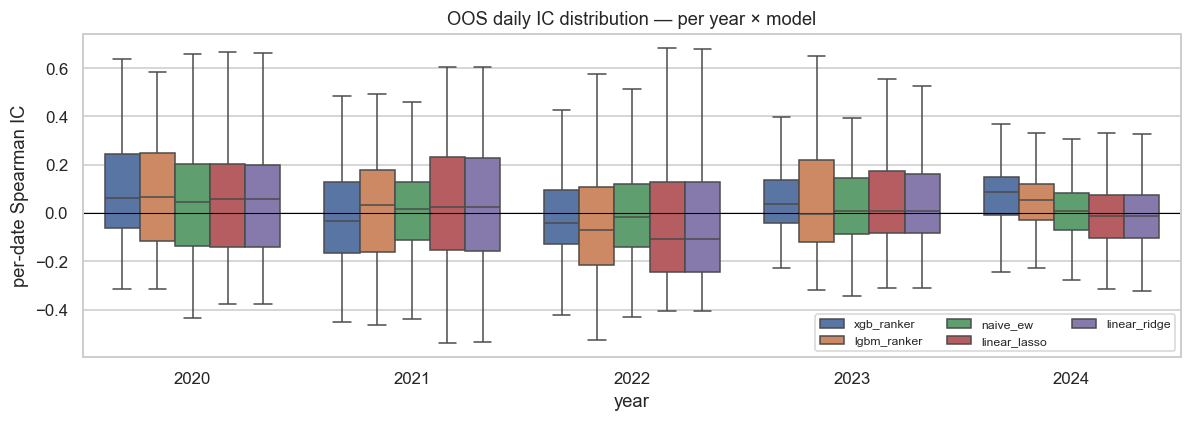

In [8]:
long = ic_wide.stack().reset_index()
long.columns = ["date", "model", "ic"]
long["year"] = long["date"].dt.year

fig, ax = plt.subplots(figsize=(11, 4))
order = summary["model"].tolist()
sns.boxplot(
    data=long, x="year", y="ic", hue="model", hue_order=order,
    showfliers=False, ax=ax,
)
ax.axhline(0, color="black", linewidth=0.7)
ax.set_title("OOS daily IC distribution — per year × model")
ax.set_ylabel("per-date Spearman IC")
ax.legend(loc="lower right", fontsize=8, ncol=3)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_per_year_ic.png", dpi=130, bbox_inches="tight")
plt.show()

In [9]:
# per-year mean IC as a table — easier to quote than read off the boxplot
pivot = long.groupby(["year", "model"])["ic"].mean().unstack("model").round(4)
pivot = pivot[order]
pivot

model,xgb_ranker,lgbm_ranker,naive_ew,linear_lasso,linear_ridge
year,,,,,
2020,0.0930,0.0740,0.0547,0.0518,0.0514
2021,-0.0222,0.0103,0.0083,0.0252,0.0250
2022,-0.0065,-0.0306,0.0051,-0.0349,-0.0351
2023,0.0583,0.0537,0.0313,0.0470,0.0452
2024,0.0610,0.0473,0.0073,-0.0057,-0.0055


## 5. Takeaways

### 5.1 The tree models do earn their complexity.
| Model | IC-IR | mean IC | t-stat |
|---|---|---|---|
| `xgb_ranker` | **0.20** | 0.037 | 6.9 |
| `lgbm_ranker` | 0.14 | 0.031 | 5.1 |
| `naive_ew` | 0.11 | 0.021 | 4.0 |
| `linear_lasso` | 0.07 | 0.017 | 2.6 |
| `linear_ridge` | 0.07 | 0.016 | 2.6 |

XGBoost beats the handmade `naive_ew` baseline by roughly 0.09 IC-IR (t-stat nearly 7 vs 4); LightGBM beats it by 0.03. The boosted ensemble is picking up non-linearity the handmade signal cannot — most plausibly the reversal flip in RSI / `ret_21d` / `macd_hist` that `01_feature_eda` flagged as wrong-signed for a linear combination.

### 5.2 Linear baselines lose to the handmade baseline.
Ridge and Lasso both come in at IC-IR ≈ 0.07, *below* the 0.11 that `naive_ew` posts with three hand-picked features. The issue is structural: the 12-feature set contains four wrong-sign features and two near-zero ones. A regularised linear model on z-scored inputs is still a linear combination — it cannot sign-flip part of the feature space, and it cannot ignore a zero-mean feature as cleanly as a tree that simply doesn't split on it. Lasso with α = 1e-4 was too weak to zero them out. This is either a tuning problem (α needs a per-fold sweep) or a fundamental limit of the linear form. I'm treating it as the latter — the tree models are the main story, and the linear baselines establish a useful floor.

### 5.3 Per-year shape is where the story gets interesting.

| Year | Regime | XGB | LGBM | naive | linear |
|---|---|---|---|---|---|
| 2020 | COVID crash + recovery | **+0.093** | +0.074 | +0.055 | +0.051 |
| 2021 | Low-vol bull continuation | −0.022 | +0.010 | +0.008 | +0.025 |
| 2022 | Rate-hike drawdown | −0.007 | **−0.031** | +0.005 | −0.035 |
| 2023 | AI rally | +0.058 | +0.054 | +0.031 | +0.047 |
| 2024 | AI rally cont'd | +0.061 | +0.047 | +0.007 | −0.006 |

Three things stand out:

1. **2022 is a shared failure.** Every learned model posted negative per-date IC across the full rate-hike year; only `naive_ew` stayed barely positive. The feature set — size, volatility, short-term reversal — had been learning "small-cap high-vol reverts" throughout 2015–2021, then got blindsided when 2022 paid the opposite trade. The models don't see the macro environment, so they couldn't adapt when the reward function flipped.

2. **XGB is the best single model but the most brittle.** It posts the highest IC in 3 of 5 years (2020, 2023, 2024) and goes negative in 2021, where LightGBM and both linears stayed positive. In production, this argues against single-model deployment — averaging the tree scores with `naive_ew` is an obvious robustness check.

3. **Naive-EW has the lowest year-over-year variance.** Mean IC is worst except in 2022, but the dispersion across years is far tighter. If the goal were stable, if modest, factor exposure, the handmade portfolio would not be a bad choice. That is a genuine tradeoff between complexity and regime robustness.

### 5.4 What this locks in for the downstream notebooks.
The main deliverable is the XGB vs naive comparison, framed honestly with the 2022 counter-example. The pitch is not "ML crushes baselines" — it's "ML earns roughly 2× the IC-IR over five years by exploiting non-linearity, at the cost of a bigger 2022 drawdown." Notebook 03 should check whether `size_adv_60` and the two vol features dominate SHAP (meaning naive-EW signals do most of the work) or whether the wrong-sign features explain the gap. Notebook 04 turns IC numbers into net PnL — an IR of 0.20 on monthly IC is not automatically 0.20 on net Sharpe after turnover.